<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Computational Statistics / Importance Sampling</h1>
<h3 style="margin: 0;  color: #1e1a66">Samoliuk Oleksandr</h3>
</div>

Imports:

In [1]:
import numpy as np
from scipy.stats import norm, uniform

import matplotlib.pyplot as plt
import seaborn as sns

---

$$
\mathbb{E}_f[h(X)] = \int_X h(x) \frac{f(x)}{g(x)} g(x) \, dx = \mathbb{E}_g\left[\frac{h(X)f(X)}{g(X)}\right] \qquad \longrightarrow \qquad \frac{1}{n} \sum_{j=1}^n \frac{h(X_j)f(X_j)}{g(X_j)} = \mathbb{E}_f[h(X)]
$$

$$h(x) = \begin{cases} 1 & \text{if } x \in [x_1, x_2] \\ 0 & \text{otherwise} \end{cases}$$

---

Importance sampling is a Monte Carlo technique that estimates expectations under a target density $f(x)$ by drawing samples from an alternative proposal density $g(x)$. By weighting each draw with the importance weight $w_i = \frac{f(X_i)}{g(X_i)}$, the weighted mean $\hat{\theta} = \frac{1}{n} \sum_{i=1}^{n} h(X_i) w_i$ provides an unbiased approximation of $\mathbb{E}_f[h(X)]$ based on samples $X_i \sim g(x)$. This approach is primarily used when direct sampling from $f(x)$ is difficult or intractable, or when variance reduction is desired by choosing $g(x)$ close to $h(x)f(x)$. Additionally, importance sampling is crucial for evaluating rare event tail probabilities where standard Monte Carlo sampling yields zero or near-zero observations due to undersampling high-impact target regions.

---

In [2]:
np.random.seed(35)
n_s = 4773
x1, x2 = 4, 6
x = np.linspace(-4.5, 8, 3000)

data = np.random.normal(loc=0, scale=1, size=n_s)

def h(x, x1, x2):
    return np.where((x1 <= x) & (x <= x2), 1, 0)

data_imps = np.random.uniform(low=x1, high=x2, size=n_s)

f_at_interval = norm.pdf(data_imps, loc=0, scale=1)
g_at_interval = uniform.pdf(data_imps, loc=x1, scale=x2 - x1)

Immediate Naive Monte Carlo Estimator - fails to detect rare events:

In [3]:
theta_n = np.mean(h(data, x1, x2))
theta_n

0.0

Importance Sampling - succeeds:

In [4]:
w_i = f_at_interval / g_at_interval
theta_imps = np.mean(h(data_imps, x1, x2) * w_i)
theta_imps

3.162506616958774e-05

Exact solution:

In [5]:
int_analytical = norm.cdf(x2) - norm.cdf(x1)
int_analytical

3.1670255245419554e-05

Plot:

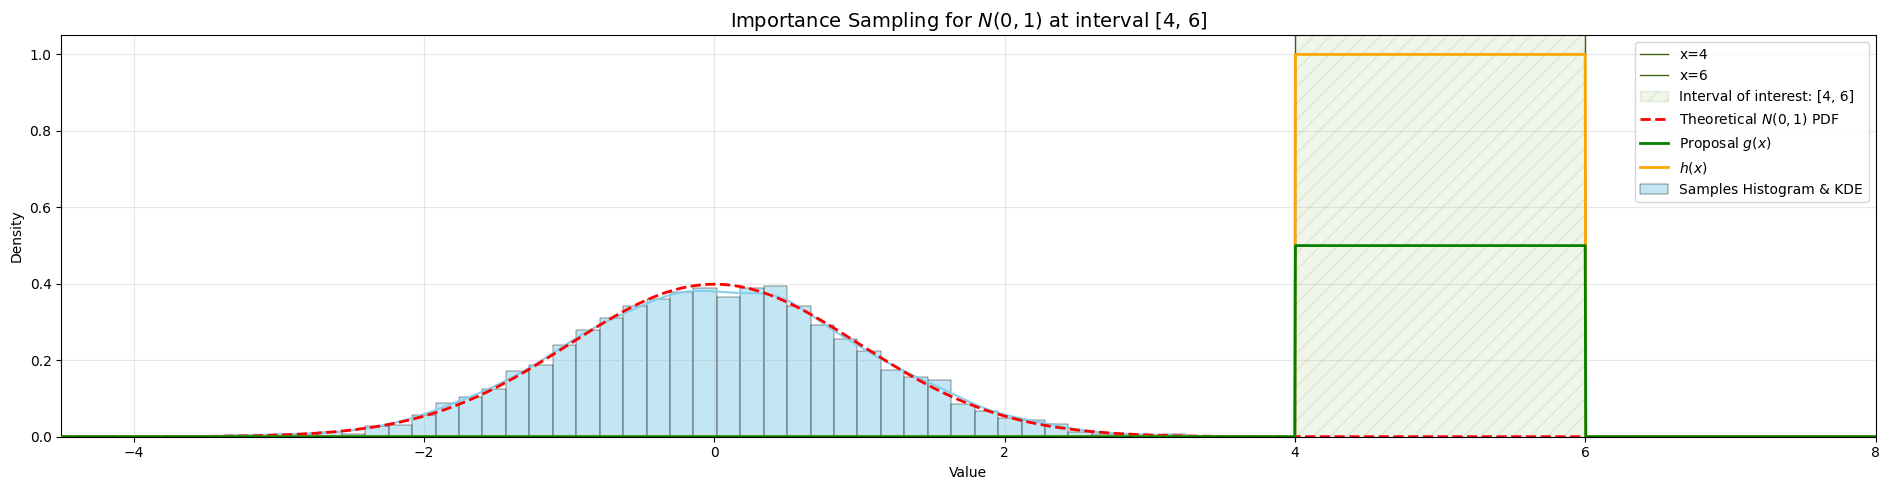

In [6]:
fig, ax = plt.subplots(figsize=(19, 5))

ax.axvline(x=x1, color="#3D640E", linewidth=1, linestyle="-", label=f"x={x1}")
ax.axvline(x=x2, color="#3D640E", linewidth=1, linestyle="-", label=f"x={x2}")
ax.axvspan(x1, x2, alpha=0.1, facecolor="#74A439B8", edgecolor="#3D640E", hatch="//", label=f"Interval of interest: [{x1}, {x2}]")

sns.histplot(
    data,
    kde=True,
    stat="density",
    color="skyblue",
    label="Samples Histogram & KDE",
    linewidth=0.3,
    ax=ax,
)

ax.plot(x, norm.pdf(x, 0, 1), "r--", label="Theoretical $N(0,1)$ PDF", linewidth=2, zorder=2)
ax.plot(x, uniform.pdf(x, loc=x1, scale=x2 - x1), "g-",label="Proposal $g(x)$", linewidth=2, zorder=3)
ax.plot(x,h(x, x1, x2), "orange", label="$h(x)$", linewidth=2)

ax.set_xlim(min(x), max(x))

ax.set_title(f"Importance Sampling for $N(0,1)$ at interval [{x1}, {x2}]", fontsize=14)
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

plt.savefig('Outputs/Importance_sampling/function_plots.png')
plt.show()

---

In [7]:
np.random.seed(35)
estimations = []
upper_bounds = []
lower_bounds = []

for n_s in range(2, 11_000):
    data_imps = np.random.uniform(low=x1, high=x2, size=n_s)

    f_at_interval = norm.pdf(data_imps, loc=0, scale=1)
    g_at_interval = uniform.pdf(data_imps, loc=x1, scale=x2 - x1)

    w_i = f_at_interval / g_at_interval
    v_i = h(data_imps, x1, x2) * w_i

    theta_imps = np.mean(v_i)
    se = np.std(v_i, ddof=1) / np.sqrt(n_s)

    estimations.append(theta_imps)
    upper_bounds.append(theta_imps + 2 * se)
    lower_bounds.append(theta_imps - 2 * se)

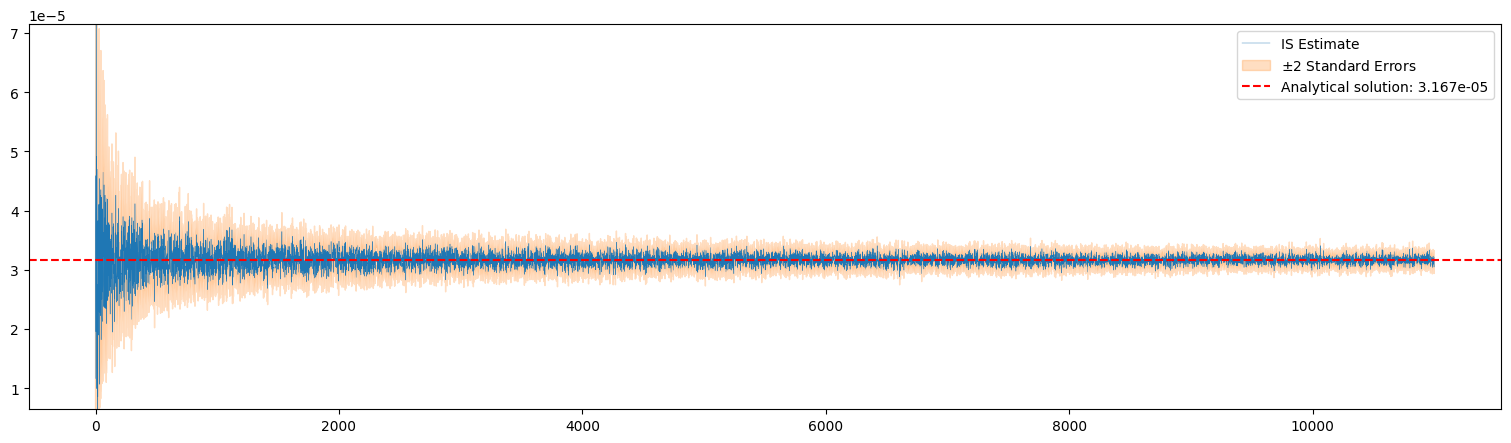

In [8]:
fig, ax = plt.subplots(figsize=(19, 5))

x_axis = range(len(estimations))
ax.plot(estimations, linewidth=0.3, label="IS Estimate")
ax.fill_between(x_axis, lower_bounds, upper_bounds, color="tab:orange", alpha=0.25, label="$\\pm 2$ Standard Errors")
ax.axhline(y=int_analytical, color='r', linestyle='--', label=f'Analytical solution: {int_analytical:.3e}')

ax.set_ylim(min(estimations), max(estimations))
plt.legend()

plt.savefig('Outputs/Importance_sampling/convergence.png')
plt.show()

---